In [1]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

C:\Users\Ibraheem khan\anaconda3\envs\tf_env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
checkpoints = r'C:\Users\Ibraheem khan\Downloads\Ml_LAB\\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

In [3]:
train_dir = r'C:\Users\Ibraheem khan\Downloads\Ml_LAB\Computer vision1\train'
validation_dir = r'C:\Users\Ibraheem khan\Downloads\Ml_LAB\Computer vision1\validation'
test_dir = r'C:\Users\Ibraheem khan\Downloads\Ml_LAB\Computer vision1\test'

In [4]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
input_shape=(256, 256, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(4, activation='sigmoid'))

C:\Users\Ibraheem khan\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,088,452 (49.93 MB)

 Trainable params: 13,088,452 (49.93 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(loss='categorical_crossentropy', optimizer=optimizers.RMSprop(learning_rate=1e-4), metrics=['acc'])

In [7]:
train_datagen = ImageDataGenerator(
                                    rescale=1./255,
                                    rotation_range=40,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    shear_range=0.2,
                                    zoom_range=0.2,
                                    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
                                                    train_dir,
                                                    target_size=(256, 256),
                                                    batch_size=32,
                                                    class_mode='categorical')

validation_generator = test_datagen.flow_from_directory(
                                                        validation_dir,
                                                        target_size=(256, 256),
                                                        batch_size=32,
                                                        class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


In [8]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32,class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(validation_dir,target_size=(256, 256),batch_size=32,class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


In [9]:
EpochCheckpoint = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
callbacks = [EpochCheckpoint]

In [10]:
model_history = model.fit(train_generator,
                         validation_data =validation_generator,
                         steps_per_epoch=train_generator.n//train_generator.batch_size, 
                         validation_steps = validation_generator.n//validation_generator.batch_size,
                         epochs =5,
                         callbacks = callbacks)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.3885 - loss: 1.2915
Epoch 1: val_loss improved from None to 0.95286, saving model to C:\Users\Ibraheem khan\Downloads\Ml_LAB\\E1-cp-0001-loss0.95.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - acc: 0.5225 - loss: 1.0992 - val_acc: 0.5670 - val_loss: 0.9529
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.7015 - loss: 0.6451
Epoch 2: val_loss improved from 0.95286 to 0.42744, saving model to C:\Users\Ibraheem khan\Downloads\Ml_LAB\\E1-cp-0002-loss0.43.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - acc: 0.7431 - loss: 0.5773 - val_acc: 0.7857 - val_loss: 0.4274
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.7871 - loss: 0.4624
Epoch 3: val_loss improved from 0.42744 to 0.37799, saving model to C:\Users\Ibraheem khan\Downloads\Ml_LAB\\E1-cp-0003-loss0.38.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - acc: 0.7969 - loss: 0.4430 - val_acc: 0.8080 - val_loss: 0.3780
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.8399 - loss: 0.3740
Epoch 4: val_loss improved from 0.37799 to 0.33865, saving model to C:\Users\Ibraheem khan\Downloads\Ml_LAB\\E1-cp-0004-loss0.34.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - acc: 0.8381 - loss: 0.3765 - val_acc: 0.8036 - val_loss: 0.3386
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc: 0.8513 - loss: 0.3294
Epoch 5: val_loss did not improve from 0.33865
50/50 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - acc: 0.8537 - loss: 0.3381 - val_acc: 0.8170 - val_loss: 0.3652


In [12]:
model_history.history

{'acc': [0.5224999785423279,
  0.7431250214576721,
  0.796875,
  0.8381249904632568,
  0.8537499904632568],
 'loss': [1.0991847515106201,
  0.5772512555122375,
  0.44297826290130615,
  0.3765318691730499,
  0.338145911693573],
 'val_acc': [0.5669642686843872,
  0.7857142686843872,
  0.8080357313156128,
  0.8035714030265808,
  0.8169642686843872],
 'val_loss': [0.9528636336326599,
  0.42743611335754395,
  0.3779903054237366,
  0.3386485278606415,
  0.3652360439300537]}

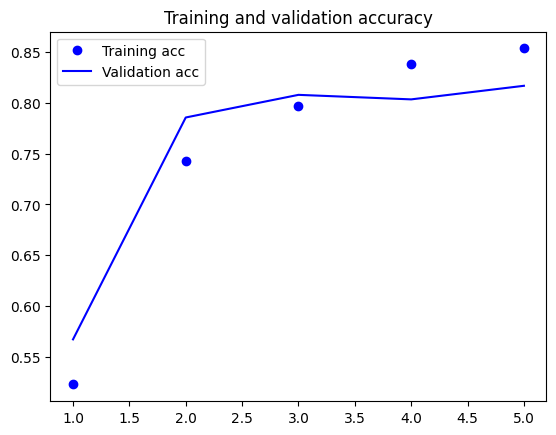

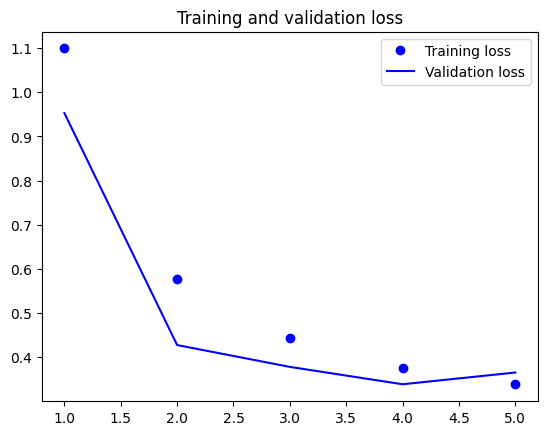

<Figure size 640x480 with 0 Axes>

In [13]:
acc = model_history.history['acc']
val_acc = model_history.history['val_acc']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()
plt.savefig(r'C:\Users\Ibraheem khan\Downloads\Ml_LAB\LAB_9\model_Accuracy.png')

Found 200 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 240ms/step


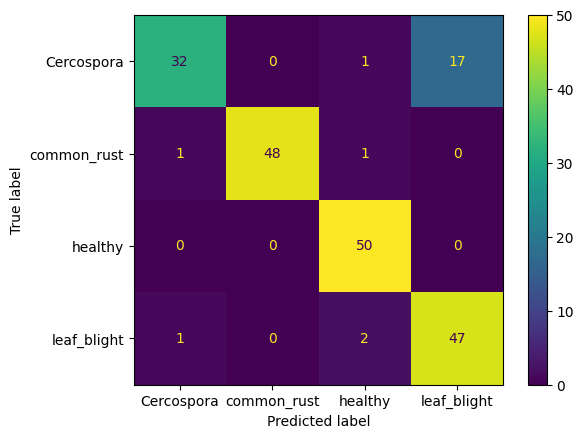

In [17]:
model = load_model(r'C:\Users\Ibraheem khan\Downloads\Ml_LAB\E1-cp-0004-loss0.34.h5')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(256, 256), batch_size=32, shuffle=False, class_mode='categorical')
label=test_generator.labels
preds=model.predict(test_generator)
pred = np.argmax(preds, axis = 1)
cm = confusion_matrix(label, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Cercospora', 'common_rust','healthy', 'leaf_blight'])
disp.plot()
plt.show()
#plt.savefig(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\confusion_matrics.jpg')

In [18]:
print(classification_report(label, pred, target_names=['Cercospora', 'common_rust','healthy', 'leaf_blight']))

              precision    recall  f1-score   support

  Cercospora       0.86      0.84      0.85        50
 common_rust       1.00      0.90      0.95        50
     healthy       0.96      1.00      0.98        50
 leaf_blight       0.87      0.94      0.90        50

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200

